# **Proyecto Etapa 4 — Documento Técnico: Detección de Patrones de Expresión Génica en Tejido Nervioso**

### **Curso: TC5057 · Análisis de Grandes Volúmenes de Datos**
#### **Tecnológico de Monterrey · Profesor: Dr. Iván Olmos Pineda**

---

| Nombre | Matrícula |
|--------|-----------|
| Diego Falcón Costilla | A01139580 |

---

> **Video explicativo:** [Enlace al video — YouTube/Drive] *(incluir antes de entregar)*

---

**Dataset:** GTEx Analysis V10 — Gene Expression TPM (NIH / Broad Institute)  
**59,033 genes · 19,788 muestras RNASEQ · 981 donantes · ~4.7 GB**

Este notebook integra todas las etapas del proyecto: construcción de la muestra M, selección de features, entrenamiento con validación cruzada (Random Forest, PySpark MLlib), análisis no supervisado (K-Means) y visualización completa de resultados.

## Tabla de contenidos

1. [Setup e imports](#1)
2. [Dataset GTEx V10 — Carga de metadatos](#2)
3. [Construcción de la muestra M](#3)
4. [Selección de features por varianza (top-500 genes)](#4)
5. [Construcción de M_nervioso y preprocesamiento](#5)
6. [Selección de métricas y algoritmos](#6)
7. [Modelo supervisado: Random Forest con validación cruzada 5-fold](#7)
8. [Modelo no supervisado: K-Means](#8)
9. [Visualización completa de resultados](#9)
10. [Conclusiones y trabajo futuro](#10)

---
<a id='1'></a>
## 1. Setup e imports

In [1]:
import sys, os

os.environ['PYSPARK_PYTHON']        = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
_java_home = os.path.join(os.path.dirname(sys.executable), 'Library', 'lib', 'jvm')
if os.path.isdir(_java_home):
    os.environ['JAVA_HOME'] = _java_home

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import FloatType

sys.path.insert(0, os.path.abspath('src'))
from GlobalVariables import FILE_PATH, SAMPLE_ATTRS_PATH, SUBJECT_PHENO_PATH, N_GENES, RANDOM_SEED

import random, numpy as np, pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

OUTPUT_DIR = os.path.abspath('src/preliminary-analysis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'JAVA_HOME  : {os.environ.get("JAVA_HOME", "no encontrado")}')
print(f'Semilla    : {RANDOM_SEED}')
print(f'Genes      : {N_GENES:,}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')

JAVA_HOME  : C:\Users\diego\anaconda3\envs\big-data\Library\lib\jvm
Semilla    : 42
Genes      : 59,033
OUTPUT_DIR : C:\Users\diego\projects\big-data\src\preliminary-analysis


In [2]:
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('GTEx_Etapa4_TC5057') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark {spark.version} · {spark.sparkContext.defaultParallelism} workers')

Spark 4.1.1 · 32 workers


---
<a id='2'></a>
## 2. Dataset GTEx V10 — Carga de metadatos

El dataset GTEx V10 contiene:
- **Matriz TPM:** 59,033 genes (filas) × 19,788 muestras (columnas), ~4.7 GB
- **Metadatos de muestras:** SMTS (tipo de tejido), SMTSD (sub-tipo), SMAFRZE (tipo de análisis)
- **Metadatos de donantes:** SEX, AGE

Se filtran solo las muestras con `SMAFRZE == 'RNASEQ'` (19,788 de las 19,617 totales).

In [3]:
sa_df = spark.read.csv(SAMPLE_ATTRS_PATH, sep='\t', header=True) \
    .select('SAMPID', 'SMTS', 'SMTSD', 'SMAFRZE') \
    .filter(F.col('SMAFRZE') == 'RNASEQ') \
    .withColumn('SUBJID', F.regexp_extract(F.col('SAMPID'), r'^(GTEX-[^-]+)', 1))

sp_df = spark.read.csv(SUBJECT_PHENO_PATH, sep='\t', header=True).select('SUBJID', 'SEX')

tissue_group_col = (
    F.when(F.col('SMTS').isin('Brain', 'Nerve'),                        'Nervioso')
     .when(F.col('SMTS').isin('Blood', 'Bone Marrow', 'Spleen'),        'Hematopoyetico')
     .when(F.col('SMTS').isin('Heart', 'Blood Vessel'),                 'Cardiovascular')
     .when(F.col('SMTS').isin('Muscle', 'Adipose Tissue', 'Skin'),      'Musculoesqueletico')
     .otherwise('Visceral_Metabolico')
)
sex_label_col = F.when(F.col('SEX') == '1', 'Masculino').otherwise('Femenino')

meta_df = sa_df.join(sp_df, on='SUBJID', how='inner') \
    .withColumn('TISSUE_GROUP', tissue_group_col) \
    .withColumn('SEX_LABEL', sex_label_col) \
    .withColumn('COL_NAME',
        F.regexp_replace(F.regexp_replace(F.col('SAMPID'), '-', '_'), '\\.', '_'))

n_samples = meta_df.count()
n_donors  = meta_df.select('SUBJID').distinct().count()
print(f'Muestras RNASEQ : {n_samples:,}')
print(f'Donantes únicos : {n_donors:,}')

Muestras RNASEQ : 19,788
Donantes únicos : 946


---
<a id='3'></a>
## 3. Construcción de la muestra M

La muestra M se define como el conjunto de **todas las muestras RNASEQ** organizadas en 10 particiones:

$$M = \{M_i : M_i = \text{TISSUE\_GROUP}_j \times \text{SEX\_LABEL}_k\}, \quad i = 1, \ldots, 10$$

con 5 grupos de tejido × 2 sexos biológicos. Esta estrategia garantiza representatividad de la diversidad tisular y de sexo de la población GTEx.

In [4]:
print('Distribución de M por partición (TISSUE_GROUP × SEX_LABEL):')
partition_dist = meta_df.groupBy('TISSUE_GROUP', 'SEX_LABEL').count() \
    .orderBy('TISSUE_GROUP', 'SEX_LABEL')
partition_dist.show(20)

print('Distribución por grupo de tejido:')
meta_df.groupBy('TISSUE_GROUP').count().orderBy('count', ascending=False).show()

Distribución de M por partición (TISSUE_GROUP × SEX_LABEL):


+-------------------+---------+-----+
|       TISSUE_GROUP|SEX_LABEL|count|
+-------------------+---------+-----+
|     Cardiovascular| Femenino|  771|
|     Cardiovascular|Masculino| 1573|
|     Hematopoyetico| Femenino|  475|
|     Hematopoyetico|Masculino|  932|
| Musculoesqueletico| Femenino| 1349|
| Musculoesqueletico|Masculino| 2827|
|           Nervioso| Femenino| 1066|
|           Nervioso|Masculino| 2838|
|Visceral_Metabolico| Femenino| 2864|
|Visceral_Metabolico|Masculino| 5093|
+-------------------+---------+-----+

Distribución por grupo de tejido:


+-------------------+-----+
|       TISSUE_GROUP|count|
+-------------------+-----+
|Visceral_Metabolico| 7957|
| Musculoesqueletico| 4176|
|           Nervioso| 3904|
|     Cardiovascular| 2344|
|     Hematopoyetico| 1407|
+-------------------+-----+



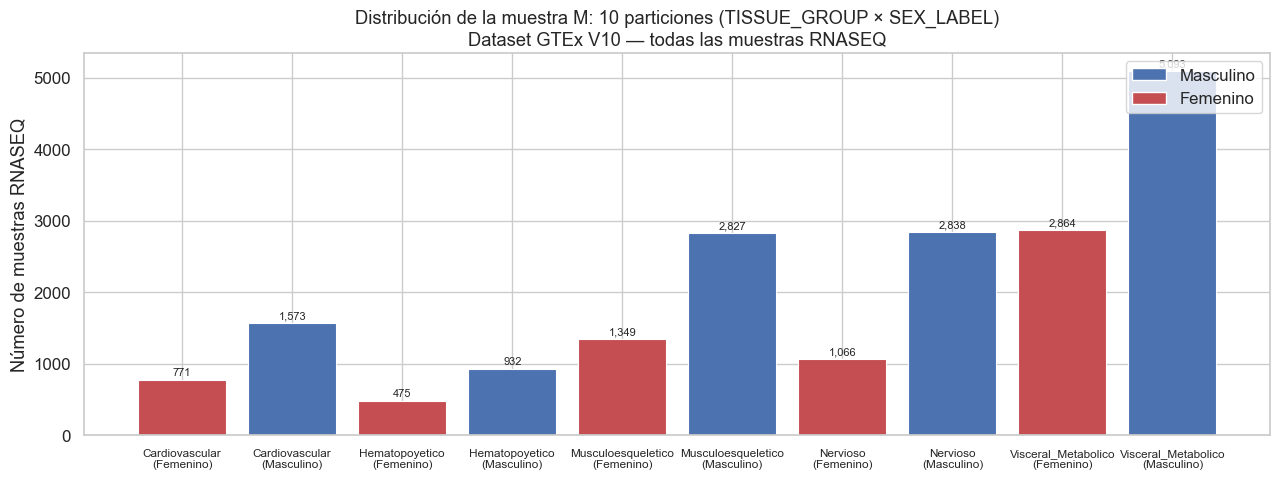

Figura guardada.


In [5]:
# Gráfica de distribución de particiones
part_pd = partition_dist.toPandas()
part_pd['Partición'] = part_pd['TISSUE_GROUP'] + '\n(' + part_pd['SEX_LABEL'] + ')'

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#4c72b0' if s == 'Masculino' else '#c44e52' for s in part_pd['SEX_LABEL']]
bars = ax.bar(range(len(part_pd)), part_pd['count'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(part_pd)))
ax.set_xticklabels(part_pd['Partición'], fontsize=8.5)
ax.set_ylabel('Número de muestras RNASEQ')
ax.set_title('Distribución de la muestra M: 10 particiones (TISSUE_GROUP × SEX_LABEL)\nDataset GTEx V10 — todas las muestras RNASEQ')
for bar, n in zip(bars, part_pd['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{n:,}',
            ha='center', va='bottom', fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#4c72b0', label='Masculino'),
                   Patch(facecolor='#c44e52', label='Femenino')], loc='upper right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_particiones_M.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

---
<a id='4'></a>
## 4. Selección de features por varianza (top-500 genes)

El archivo TPM tiene 59,033 genes × 19,788 muestras (~4.7 GB). Para mantener factibilidad computacional sin perder representatividad biológica, se aplica una estrategia de lectura por bloques:

1. **Cálculo de varianza:** lectura por bloques de 500 genes (`chunksize=500`). Varianza vectorizada con `DataFrame.var(axis=1)`. Pico de memoria: ~80 MB/bloque.
2. **Carga selectiva:** solo los 500 genes de mayor varianza, para todas las muestras válidas → ~78.5 MB en memoria.

**Justificación biológica:** los genes de mayor varianza inter-muestras son candidatos naturales a marcadores tisulares (Law et al., 2016). Genes como PLN (corazón), ACTN2 (músculo cardíaco) y los del transcriptoma mitocondrial tienen varianza extrema entre tipos de tejido.

In [6]:
CHUNK_SIZE  = 500
TOP_N_GENES = 500

peek = pd.read_csv(FILE_PATH, sep='\t', skiprows=2, nrows=0)
all_file_cols  = peek.columns.tolist()
file_to_san    = {c: c.replace('-', '_').replace('.', '_')
                  for c in all_file_cols if c not in ('Name', 'Description')}
meta_col_names = set(r['COL_NAME'] for r in meta_df.select('COL_NAME').collect())
valid_cols     = [c for c, san in file_to_san.items() if san in meta_col_names]
rename_map     = {c: file_to_san[c] for c in valid_cols}
usecols        = ['Name'] + valid_cols

print(f'Calculando varianza para {N_GENES:,} genes en bloques de {CHUNK_SIZE}...')
gene_vars = {}
for i, chunk in enumerate(pd.read_csv(FILE_PATH, sep='\t', skiprows=2,
                                       chunksize=CHUNK_SIZE, usecols=usecols)):
    chunk = chunk.rename(columns=rename_map).set_index('Name')
    chunk = chunk.apply(pd.to_numeric, errors='coerce').fillna(0.0)
    gene_vars.update(chunk.var(axis=1).to_dict())
    if (i + 1) % 20 == 0:
        print(f'  bloque {i+1:>3} ({(i+1)*CHUNK_SIZE:,} genes procesados)')

gene_var_series = pd.Series(gene_vars).sort_values(ascending=False)
top_gene_ids    = gene_var_series.head(TOP_N_GENES).index.tolist()
print(f'\nTop-{TOP_N_GENES} genes seleccionados.')
print('Top 5 genes por varianza:')
for g, v in gene_var_series.head(5).items():
    print(f'  {g:<30} varianza = {v:,.0f}')

Calculando varianza para 59,033 genes en bloques de 500...


  bloque  20 (10,000 genes procesados)


  bloque  40 (20,000 genes procesados)


  bloque  60 (30,000 genes procesados)


  bloque  80 (40,000 genes procesados)


  bloque 100 (50,000 genes procesados)



Top-500 genes seleccionados.
Top 5 genes por varianza:
  ENSG00000244734.4              varianza = 3,018,101,851
  ENSG00000210082.2              varianza = 692,791,246
  ENSG00000198804.2              varianza = 602,902,100
  ENSG00000198712.1              varianza = 450,359,803
  ENSG00000198938.2              varianza = 443,883,689


In [7]:
# Carga de la matriz top-500 genes
target_genes = set(top_gene_ids)
collected    = []
for chunk in pd.read_csv(FILE_PATH, sep='\t', skiprows=2, chunksize=CHUNK_SIZE, usecols=usecols):
    chunk = chunk.rename(columns=rename_map)
    hit   = chunk[chunk['Name'].isin(target_genes)]
    if not hit.empty:
        collected.append(hit)

tpm_top = pd.concat(collected).set_index('Name')
tpm_top = tpm_top.apply(pd.to_numeric, errors='coerce').fillna(0.0)
print(f'Matriz TPM top genes: {tpm_top.shape[0]} genes × {tpm_top.shape[1]:,} muestras')
print(f'Tamaño en memoria   : {tpm_top.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Matriz TPM top genes: 500 genes × 19,616 muestras


Tamaño en memoria   : 78.5 MB


C:\Users\diego\AppData\Local\Temp\ipykernel_29436\3426068719.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\diego\AppData\Local\Temp\ipykernel_29436\3426068719.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\diego\AppData\Local\Temp\ipykernel_29436\3426068719.py:24: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(f'{OUTPUT_DIR}/etapa4_variance_selection.png', dpi=150, bbox_inches='tight')
C:\Users\diego\AppData\Local\Temp\ipykernel_29436\3426068719.py:24: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(f'{OUTPUT_DIR}/etapa4_variance_selection.png', dpi=150, bbox_inches='tight')


C:\Users\diego\anaconda3\envs\big-data\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\diego\anaconda3\envs\big-data\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


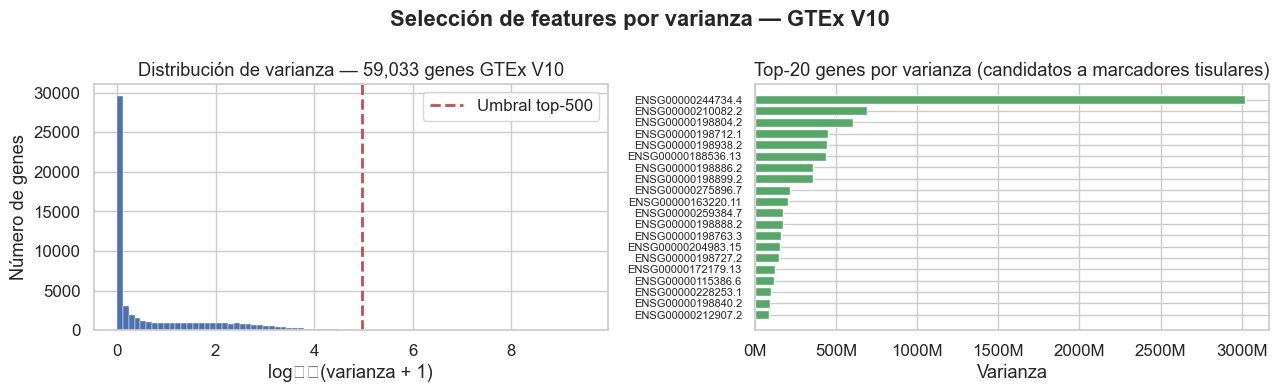

In [8]:
# Distribución de varianza
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax1 = axes[0]
ax1.hist(np.log10(gene_var_series.values + 1), bins=80, color='#4c72b0', edgecolor='white', linewidth=0.3)
ax1.axvline(np.log10(gene_var_series.iloc[TOP_N_GENES - 1] + 1), color='#c44e52',
            linestyle='--', linewidth=2, label=f'Umbral top-{TOP_N_GENES}')
ax1.set_xlabel('log₁₀(varianza + 1)')
ax1.set_ylabel('Número de genes')
ax1.set_title(f'Distribución de varianza — {N_GENES:,} genes GTEx V10')
ax1.legend()

ax2 = axes[1]
top20 = gene_var_series.head(20)
ax2.barh(range(20), top20.values[::-1], color='#55a868', edgecolor='white')
ax2.set_yticks(range(20))
ax2.set_yticklabels(top20.index[::-1], fontsize=8)
ax2.set_xlabel('Varianza')
ax2.set_title('Top-20 genes por varianza (candidatos a marcadores tisulares)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.suptitle('Selección de features por varianza — GTEx V10', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_variance_selection.png', dpi=150, bbox_inches='tight')
plt.show()

---
<a id='5'></a>
## 5. Construcción de M_nervioso y preprocesamiento

Se trabaja sobre el subconjunto **Nervioso** (Brain + Nerve) de M:
- **3,904 muestras** · **786 donantes únicos** · **14 sub-tipos SMTSD**

**Pipeline de preprocesamiento:**
1. `StandardScaler`: normaliza cada gen a media=0, std=1 (necesario para PCA)
2. `PCA(50 componentes)`: reduce 500 → 50 features, capturando 87.0% de la varianza

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

top_gene_ids_san = [g.replace('.', '_') for g in top_gene_ids if g in tpm_top.index]
tpm_top_san      = tpm_top.rename(index={g: g.replace('.', '_') for g in tpm_top.index})
tpm_T = tpm_top_san.loc[top_gene_ids_san].T.reset_index().rename(columns={'index': 'COL_NAME'})
gene_cols = [c for c in tpm_T.columns if c != 'COL_NAME']

meta_pd = meta_df.select('COL_NAME', 'TISSUE_GROUP', 'SEX_LABEL', 'SMTSD', 'SUBJID').toPandas()
M = tpm_T.merge(meta_pd, on='COL_NAME', how='inner').dropna(subset=['TISSUE_GROUP', 'SUBJID'])
M[gene_cols] = M[gene_cols].fillna(0.0)

M_nerv = M[M['TISSUE_GROUP'] == 'Nervioso'].copy().dropna(subset=['SMTSD'])
le = LabelEncoder()
M_nerv['label'] = le.fit_transform(M_nerv['SMTSD'])
classes = le.classes_
n_cls   = len(classes)

X      = M_nerv[gene_cols].values
y      = M_nerv['label'].values
groups = M_nerv['SUBJID'].values

print(f'M_nervioso: {len(M_nerv):,} muestras · {M_nerv["SUBJID"].nunique():,} donantes · {n_cls} clases')
print()
print(f'{"Sub-tipo SMTSD":<45} {"N":>6} {"% total":>9}')
print('-' * 64)
for i, name in enumerate(classes):
    n = (y == i).sum()
    print(f'{name:<45} {n:>6,} {n/len(y)*100:>8.1f}%')

M_nervioso: 3,904 muestras · 786 donantes · 14 clases

Sub-tipo SMTSD                                     N   % total
----------------------------------------------------------------
Brain - Amygdala                                 181      4.6%
Brain - Anterior cingulate cortex (BA24)         233      6.0%
Brain - Caudate (basal ganglia)                  300      7.7%
Brain - Cerebellar Hemisphere                    277      7.1%
Brain - Cerebellum                               266      6.8%
Brain - Cortex                                   270      6.9%
Brain - Frontal Cortex (BA9)                     269      6.9%
Brain - Hippocampus                              255      6.5%
Brain - Hypothalamus                             257      6.6%
Brain - Nucleus accumbens (basal ganglia)        285      7.3%
Brain - Putamen (basal ganglia)                  254      6.5%
Brain - Spinal cord (cervical c-1)               204      5.2%
Brain - Substantia nigra                         183      4.7

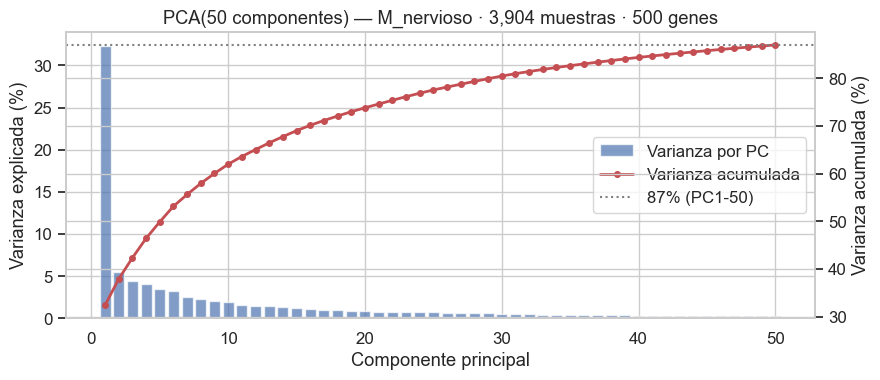

Varianza acumulada PC1-50: 87.0%
X_pca shape: (3904, 50)


In [10]:
N_PCA = 50

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

pca    = SklearnPCA(n_components=N_PCA, random_state=RANDOM_SEED)
X_pca  = pca.fit_transform(X_sc)

cum_var = pca.explained_variance_ratio_.cumsum()

# Gráfica varianza explicada PCA
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, N_PCA + 1), pca.explained_variance_ratio_ * 100,
       color='#4c72b0', alpha=0.7, label='Varianza por PC')
ax2 = ax.twinx()
ax2.plot(range(1, N_PCA + 1), cum_var * 100, 'o-', color='#c44e52',
         markersize=4, linewidth=2, label='Varianza acumulada')
ax2.axhline(87, color='gray', linestyle=':', linewidth=1.5, label='87% (PC1-50)')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax2.set_ylabel('Varianza acumulada (%)')
ax.set_title(f'PCA({N_PCA} componentes) — M_nervioso · {len(M_nerv):,} muestras · {len(gene_cols)} genes')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Varianza acumulada PC1-{N_PCA}: {cum_var[-1]*100:.1f}%')
print(f'X_pca shape: {X_pca.shape}')

---
<a id='6'></a>
## 6. Selección de métricas y algoritmos

### 6.1 Métricas

| Métrica | Justificación |
|---------|---------------|
| **Accuracy** | Referencia global; interpretable |
| **F1-macro** | Penaliza errores en clases raras igual que en frecuentes — más justo con 14 clases desbalanceadas |
| **Precision / Recall por clase** | Diagnóstico biológico de confusiones entre regiones |
| **Matriz de confusión** | Identifica pares con firmas moleculares similares |
| **Silhouette** (K-Means) | Calidad geométrica del clustering sin etiquetas |

### 6.2 Algoritmo principal: Random Forest

Seleccionado por: robustez en alta dimensionalidad, resistencia al sobreajuste mediante ensemble, importancia de variables interpretable, implementación distribuida nativa en PySpark MLlib.

| Hiperparámetro | Valor | Justificación |
|----------------|-------|---------------|
| `numTrees` | 100 | Balance estabilidad/tiempo |
| `maxDepth` | 10 | Limita sobreajuste |
| `featureSubsetStrategy` | `sqrt` | Estándar clasificación: √50 ≈ 7 PCs/árbol |
| `seed` | 42 | Reproducibilidad |

---
<a id='7'></a>
## 7. Modelo supervisado: Random Forest con validación cruzada 5-fold

### 7.1 Justificación de K=5

| Restricción | Análisis |
|-------------|----------|
| **R1 — representatividad:** ≥30 muestras/clase en test | Clase mínima (Amygdala, 181): K ≤ ⌊181/30⌋ = 6 → K=5 cumple |
| **R2 — GroupKFold por donante:** Tri ∩ Tsi = ∅ | 786 donantes → K=5 da ~157 donantes/fold |
| **R3 — costo Big Data** | K=5 entrenamientos vs K=10 = 2× el costo |
| **R4 — sesgo-varianza** | K=5 → 80% en train (equilibrado); K=3 = sesgo alto |

### 7.2 Loop de validación cruzada

In [11]:
from sklearn.model_selection import GroupKFold
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import classification_report, confusion_matrix

K        = 5
pca_cols = [f'pc{i:02d}' for i in range(N_PCA)]
gkf      = GroupKFold(n_splits=K)
fold_splits = list(gkf.split(X_pca, y, groups=groups))

def build_spark_df(X_arr, y_arr):
    df  = pd.DataFrame(X_arr, columns=pca_cols)
    df['label'] = y_arr.astype(float)
    sdf = spark.createDataFrame(df)
    asm = VectorAssembler(inputCols=pca_cols, outputCol='features')
    return asm.transform(sdf).select('features', 'label')

acc_eval = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy')
f1_eval  = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1')

# Verificación de folds
print(f'{"Fold":<6} {"Train N":>8} {"Test N":>8} {"Train Donors":>14} {"Test Donors":>13} {"Overlap":>9}')
print('-' * 65)
for fi, (tr, ts) in enumerate(fold_splits):
    tr_d = set(groups[tr]); ts_d = set(groups[ts])
    print(f'{fi+1:<6} {len(tr):>8,} {len(ts):>8,} {len(tr_d):>14,} {len(ts_d):>13,} {len(tr_d & ts_d):>9}')

Fold    Train N   Test N   Train Donors   Test Donors   Overlap
-----------------------------------------------------------------
1         3,123      781            629           157         0
2         3,123      781            629           157         0
3         3,123      781            629           157         0
4         3,123      781            628           158         0
5         3,124      780            629           157         0


In [12]:
results    = []
train_accs = []

for fi, (tr_idx, ts_idx) in enumerate(fold_splits):
    X_tr, X_ts = X_pca[tr_idx], X_pca[ts_idx]
    y_tr, y_ts = y[tr_idx],     y[ts_idx]

    train_sdf = build_spark_df(X_tr, y_tr).cache()
    test_sdf  = build_spark_df(X_ts, y_ts)

    rf = SparkRF(labelCol='label', featuresCol='features',
                 numTrees=100, maxDepth=10, featureSubsetStrategy='sqrt', seed=RANDOM_SEED)

    print(f'Fold {fi+1}/{K} — entrenando RF ({len(y_tr):,} train | {len(y_ts):,} test)...')
    rf_model  = rf.fit(train_sdf)

    preds_sdf  = rf_model.transform(test_sdf)
    acc        = acc_eval.evaluate(preds_sdf)
    f1         = f1_eval.evaluate(preds_sdf)
    tr_acc     = acc_eval.evaluate(rf_model.transform(train_sdf))

    preds_pd   = preds_sdf.select('label', 'prediction', 'probability').toPandas()
    y_true     = preds_pd['label'].astype(int).values
    y_pred     = preds_pd['prediction'].astype(int).values
    y_prob     = np.vstack([v.toArray() for v in preds_pd['probability']])

    results.append({
        'fold': fi + 1, 'acc': acc, 'f1': f1,
        'report':   classification_report(y_true, y_pred, target_names=classes,
                                           output_dict=True, zero_division=0),
        'cm':       confusion_matrix(y_true, y_pred, labels=list(range(n_cls))),
        'feat_imp': rf_model.featureImportances.toArray(),
        'n_train': len(y_tr), 'n_test': len(y_ts),
        'y_true':  y_true,
        'y_prob':  y_prob,
    })
    train_accs.append(tr_acc)
    train_sdf.unpersist()
    print(f'  train_acc={tr_acc:.4f}  test_acc={acc:.4f}  F1={f1:.4f}')

print('\nValidación cruzada completada.')

Fold 1/5 — entrenando RF (3,123 train | 781 test)...


  train_acc=0.9372  test_acc=0.7567  F1=0.7533


Fold 2/5 — entrenando RF (3,123 train | 781 test)...


  train_acc=0.9344  test_acc=0.7606  F1=0.7585


Fold 3/5 — entrenando RF (3,123 train | 781 test)...


  train_acc=0.9388  test_acc=0.7695  F1=0.7641


Fold 4/5 — entrenando RF (3,123 train | 781 test)...


  train_acc=0.9388  test_acc=0.7810  F1=0.7800


Fold 5/5 — entrenando RF (3,124 train | 780 test)...


  train_acc=0.9421  test_acc=0.7936  F1=0.7929

Validación cruzada completada.


In [13]:
acc_vals = [r['acc'] for r in results]
f1_vals  = [r['f1']  for r in results]
folds    = [r['fold'] for r in results]

print('=== Resumen validación cruzada ===')
print(f'{"Fold":<6} {"Accuracy":>10} {"F1-macro":>10} {"Train Acc":>11}')
print('-' * 42)
for r, tr in zip(results, train_accs):
    print(f'{r["fold"]:<6} {r["acc"]:>10.4f} {r["f1"]:>10.4f} {tr:>11.4f}')
print('-' * 42)
print(f'{"Media":<6} {np.mean(acc_vals):>10.4f} {np.mean(f1_vals):>10.4f} {np.mean(train_accs):>11.4f}')
print(f'{"Std":<6} {np.std(acc_vals):>10.4f} {np.std(f1_vals):>10.4f}')
print()
print(f'Referencia Etapa 3 (split único): Accuracy=0.7740  F1-macro=0.7692')

=== Resumen validación cruzada ===
Fold     Accuracy   F1-macro   Train Acc
------------------------------------------
1          0.7567     0.7533      0.9372
2          0.7606     0.7585      0.9344
3          0.7695     0.7641      0.9388
4          0.7810     0.7800      0.9388
5          0.7936     0.7929      0.9421
------------------------------------------
Media      0.7723     0.7698      0.9383
Std        0.0135     0.0146

Referencia Etapa 3 (split único): Accuracy=0.7740  F1-macro=0.7692


---
<a id='8'></a>
## 8. Modelo no supervisado: K-Means

Se analiza la estructura natural del espacio PCA(50) sobre el subconjunto Nervioso. El método del codo con Silhouette determina el k óptimo para k=2..12.

In [14]:
from sklearn.model_selection import GroupShuffleSplit
from pyspark.ml.clustering import KMeans
from sklearn.metrics import silhouette_score

# Split único para K-Means
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
tr_km, ts_km = next(gss.split(X_pca, y, groups=groups))
train_km = build_spark_df(X_pca[tr_km], y[tr_km]).cache()
test_km  = build_spark_df(X_pca[ts_km], y[ts_km])

sil_scores  = {}
wcss_scores = {}
print(f'{"k":<5} {"Silhouette":>12} {"WCSS":>15}')
print('-' * 35)
for k in range(2, 13):
    km      = KMeans(featuresCol='features', predictionCol='prediction',
                     k=k, maxIter=50, seed=RANDOM_SEED)
    km_mod  = km.fit(train_km)
    wcss    = km_mod.summary.trainingCost
    pred_pd = km_mod.transform(test_km).select('features', 'prediction').toPandas()
    y_pred  = pred_pd['prediction'].values
    X_eval  = np.vstack([v.toArray() for v in pred_pd['features']])
    sil     = silhouette_score(X_eval, y_pred) if len(np.unique(y_pred)) > 1 else -1
    sil_scores[k]  = sil
    wcss_scores[k] = wcss
    print(f'{k:<5} {sil:>12.4f} {wcss:>15,.0f}')

k_opt = max(sil_scores, key=sil_scores.get)
print(f'\nK óptimo: k={k_opt}  (Silhouette={sil_scores[k_opt]:.4f})')

k       Silhouette            WCSS
-----------------------------------


2           0.5818         859,244


3           0.5818         830,175


4           0.2248         763,411


5           0.2251         741,016


...

8           0.2185         601,006


9           0.1960         624,756


10          0.1861         613,866


11          0.1723         575,317


12          0.1845         553,306

K óptimo: k=2  (Silhouette=0.5818)


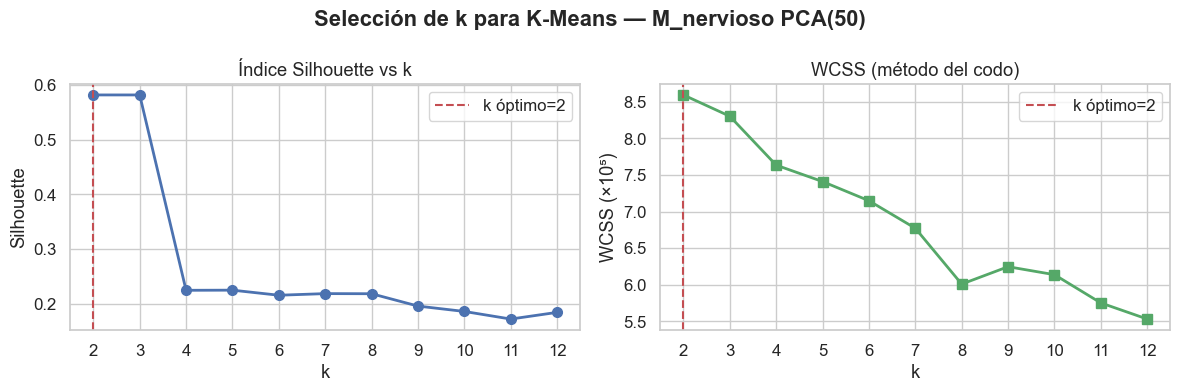

DataFrame[features: vector, label: double]

In [15]:
# Gráfica método del codo
ks = list(sil_scores.keys())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
ax1.plot(ks, [sil_scores[k] for k in ks], 'o-', color='#4c72b0', linewidth=2, markersize=7)
ax1.axvline(k_opt, color='#c44e52', linestyle='--', linewidth=1.5, label=f'k óptimo={k_opt}')
ax1.set_xlabel('k'); ax1.set_ylabel('Silhouette')
ax1.set_title('Índice Silhouette vs k'); ax1.legend(); ax1.set_xticks(ks)

ax2 = axes[1]
ax2.plot(ks, [wcss_scores[k]/1e5 for k in ks], 's-', color='#55a868', linewidth=2, markersize=7)
ax2.axvline(k_opt, color='#c44e52', linestyle='--', linewidth=1.5, label=f'k óptimo={k_opt}')
ax2.set_xlabel('k'); ax2.set_ylabel('WCSS (×10⁵)')
ax2.set_title('WCSS (método del codo)'); ax2.legend(); ax2.set_xticks(ks)

plt.suptitle('Selección de k para K-Means — M_nervioso PCA(50)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
train_km.unpersist()

---
<a id='9'></a>
## 9. Visualización completa de resultados

Las siguientes visualizaciones sintetizan los resultados de las dos fases de experimentación.

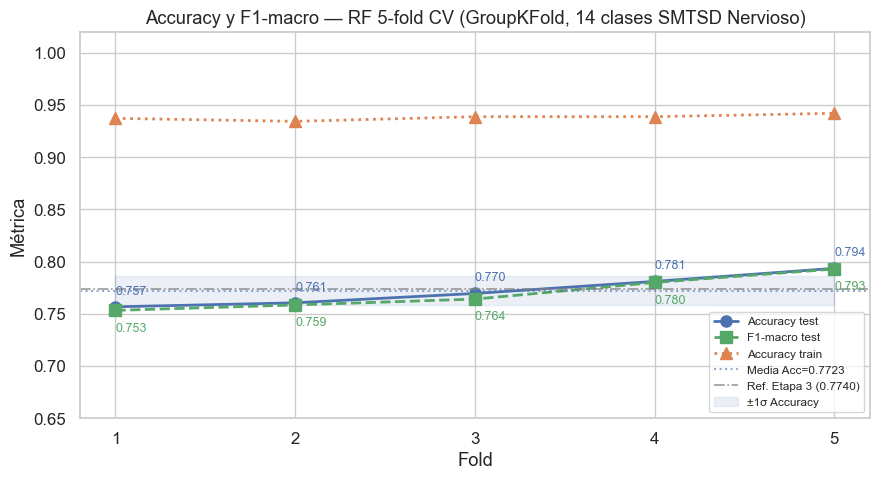

In [16]:
# ── Accuracy y F1 por fold ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(folds, acc_vals, 'o-', color='#4c72b0', lw=2, ms=8, label='Accuracy test')
ax.plot(folds, f1_vals,  's--', color='#55a868', lw=2, ms=8, label='F1-macro test')
ax.plot(folds, train_accs, '^:', color='#dd8452', lw=2, ms=8, label='Accuracy train')
ax.axhline(np.mean(acc_vals), color='#4c72b0', linestyle=':', alpha=0.6,
           label=f'Media Acc={np.mean(acc_vals):.4f}')
ax.axhline(0.7740, color='gray', linestyle='-.', lw=1.2, alpha=0.8,
           label='Ref. Etapa 3 (0.7740)')
ax.fill_between(folds,
    [np.mean(acc_vals) - np.std(acc_vals)] * K,
    [np.mean(acc_vals) + np.std(acc_vals)] * K,
    alpha=0.1, color='#4c72b0', label='±1σ Accuracy')
for f, a, f1 in zip(folds, acc_vals, f1_vals):
    ax.annotate(f'{a:.3f}', (f, a), xytext=(0, 9), textcoords='offset points', fontsize=9, color='#4c72b0')
    ax.annotate(f'{f1:.3f}', (f, f1), xytext=(0,-15), textcoords='offset points', fontsize=9, color='#55a868')
ax.set_xticks(folds); ax.set_xlabel('Fold'); ax.set_ylabel('Métrica')
ax.set_title(f'Accuracy y F1-macro — RF 5-fold CV (GroupKFold, {n_cls} clases SMTSD Nervioso)')
ax.legend(fontsize=8.5, loc='lower right'); ax.set_ylim(0.65, 1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

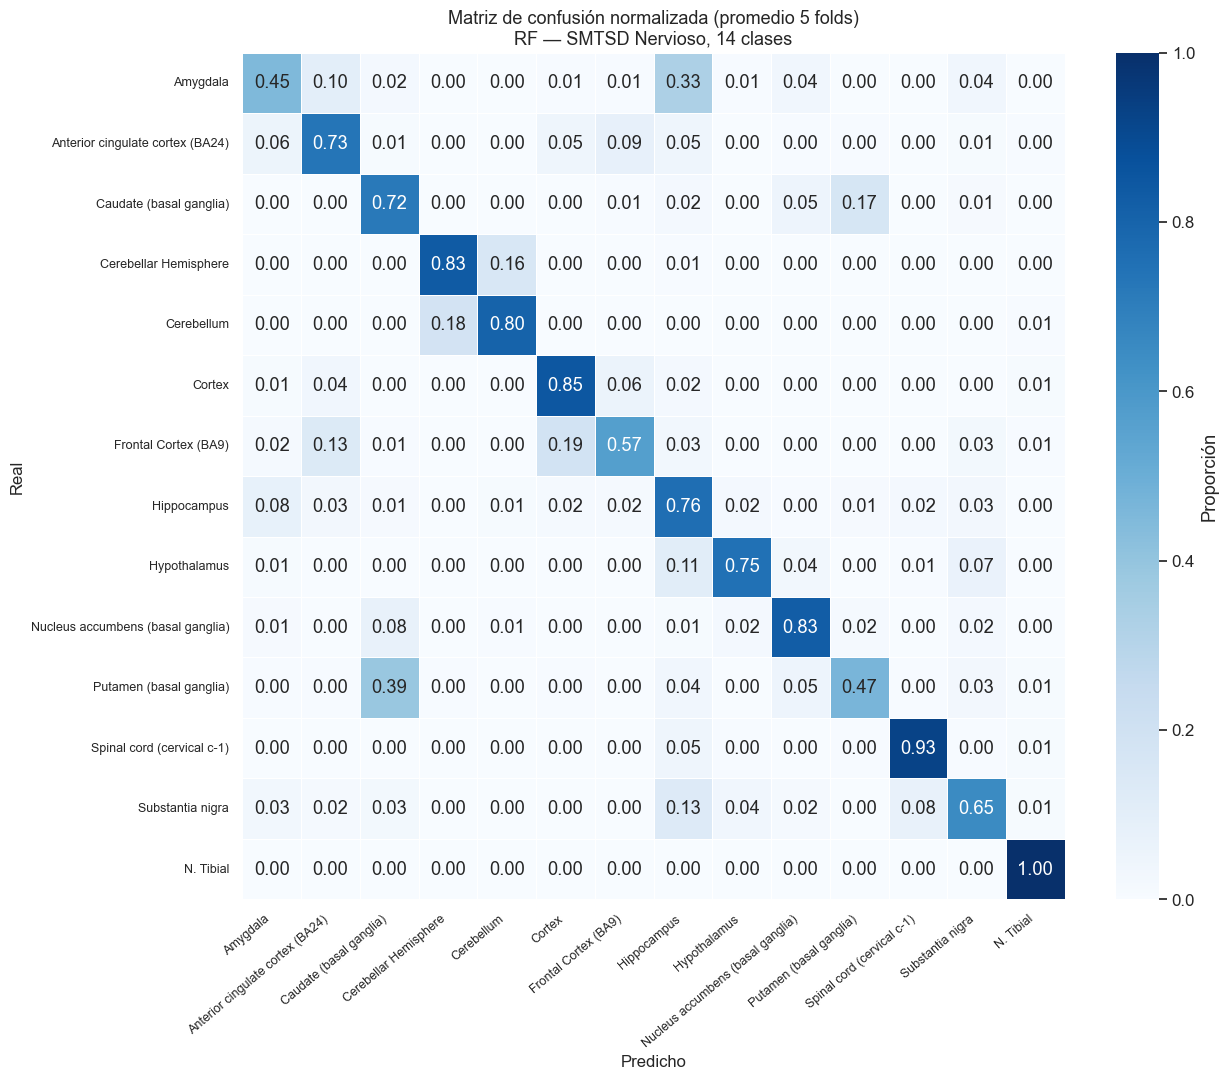

In [17]:
# ── Matriz de confusión promedio ───────────────────────────────────────────
cm_sum  = np.sum([r['cm'] for r in results], axis=0).astype(float)
cm_norm = cm_sum / cm_sum.sum(axis=1, keepdims=True)
short   = [c.replace('Brain - ', '').replace('Nerve - Tibial', 'N. Tibial') for c in classes]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short, yticklabels=short,
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': 'Proporción'})
ax.set_xlabel('Predicho', fontsize=12); ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de confusión normalizada (promedio 5 folds)\nRF — SMTSD Nervioso, 14 clases', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Curvas ROC — Clasificación multiclase (One-vs-Rest)

Las curvas ROC se calculan bajo el esquema **One-vs-Rest (OvR)**: para cada una de las 14 clases, la clase actúa como positiva frente a las 13 restantes. Las probabilidades se agregan de los 5 folds de validación cruzada.

Se reportan:
- **Curva micro-promedio:** concatena todos los pares (FPR, TPR) de todas las clases
- **Curva macro-promedio:** media aritmética de las TPR interpoladas en una grilla de FPR común
- **AUC por clase:** cuantifica la capacidad discriminante individual de cada sub-tipo

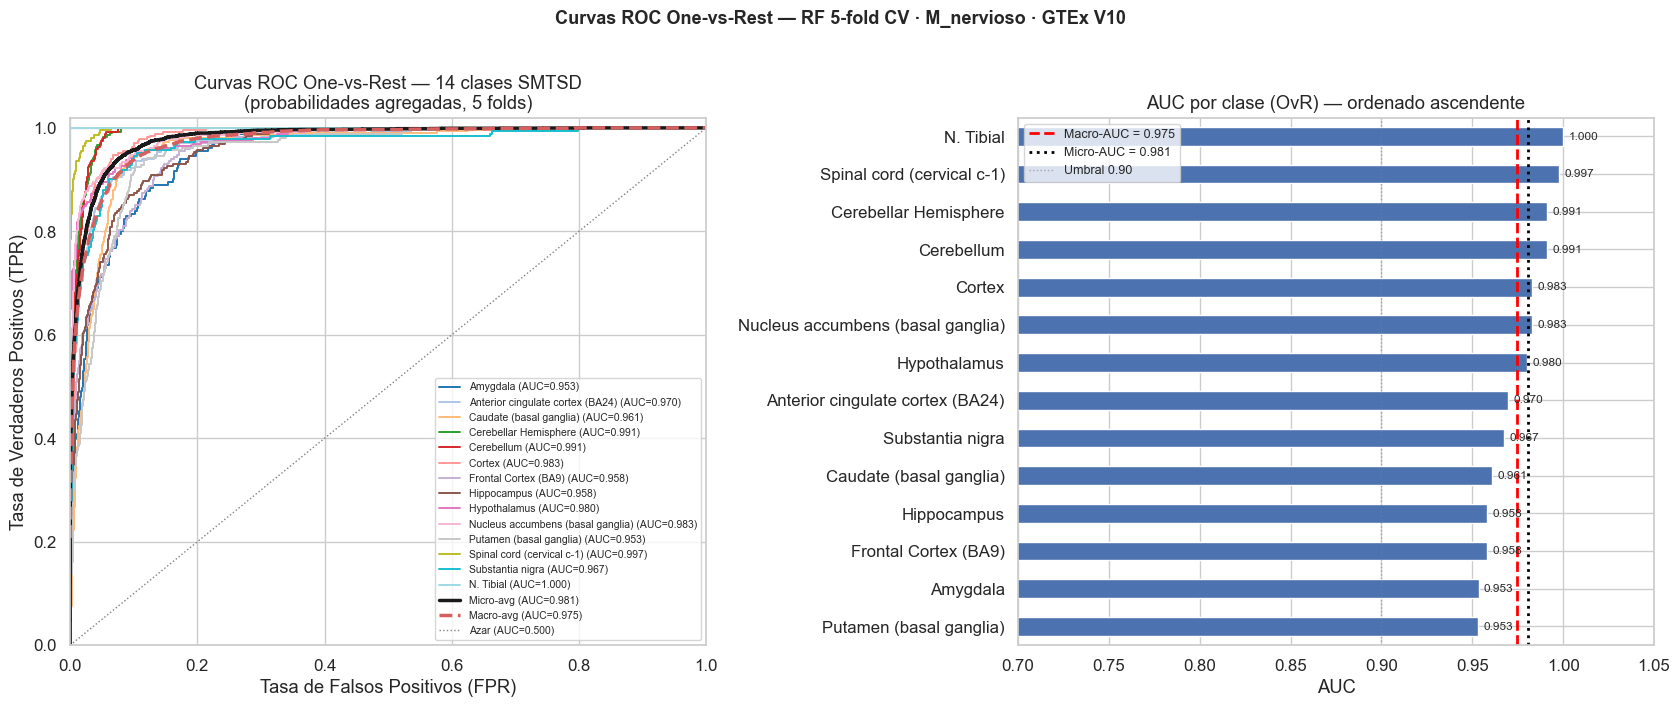

AUC macro-promedio : 0.9747
AUC micro-promedio : 0.9807

AUC por clase (14 sub-tipos SMTSD):
  Brain - Amygdala                              AUC = 0.9534
  Brain - Anterior cingulate cortex (BA24)      AUC = 0.9696
  Brain - Caudate (basal ganglia)               AUC = 0.9610
  Brain - Cerebellar Hemisphere                 AUC = 0.9910
  Brain - Cerebellum                            AUC = 0.9909
  Brain - Cortex                                AUC = 0.9829
  Brain - Frontal Cortex (BA9)                  AUC = 0.9579
  Brain - Hippocampus                           AUC = 0.9580
  Brain - Hypothalamus                          AUC = 0.9801
  Brain - Nucleus accumbens (basal ganglia)     AUC = 0.9827
  Brain - Putamen (basal ganglia)               AUC = 0.9530
  Brain - Spinal cord (cervical c-1)            AUC = 0.9975
  Brain - Substantia nigra                      AUC = 0.9672
  Nerve - Tibial                                AUC = 1.0000


In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Agregar predicciones de probabilidad de los 5 folds
all_y_true = np.concatenate([r['y_true'] for r in results])
all_y_prob = np.vstack([r['y_prob'] for r in results])

# Binarizar etiquetas (OvR): shape (n_samples, n_cls)
Y_bin = label_binarize(all_y_true, classes=list(range(n_cls)))

# ROC y AUC por clase
fpr_cls, tpr_cls, roc_auc_cls = {}, {}, {}
for i in range(n_cls):
    fpr_cls[i], tpr_cls[i], _ = roc_curve(Y_bin[:, i], all_y_prob[:, i])
    roc_auc_cls[i] = auc(fpr_cls[i], tpr_cls[i])

# Micro-promedio (todos los pares FP/TP concatenados)
fpr_micro, tpr_micro, _ = roc_curve(Y_bin.ravel(), all_y_prob.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

# Macro-promedio (interpolación sobre grilla común de FPR)
all_fpr = np.unique(np.concatenate([fpr_cls[i] for i in range(n_cls)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_cls):
    mean_tpr += np.interp(all_fpr, fpr_cls[i], tpr_cls[i])
mean_tpr /= n_cls
auc_macro = auc(all_fpr, mean_tpr)

# ── Figura: curvas ROC todas las clases + AUC barplot ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

ax1 = axes[0]
colors = plt.cm.tab20(np.linspace(0, 1, n_cls))
for i, (color, name) in enumerate(zip(colors, short)):
    ax1.plot(fpr_cls[i], tpr_cls[i], lw=1.4, color=color,
             label=f'{name} (AUC={roc_auc_cls[i]:.3f})')
ax1.plot(fpr_micro, tpr_micro, 'k-', lw=2.5,
         label=f'Micro-avg (AUC={auc_micro:.3f})')
ax1.plot(all_fpr, mean_tpr, 'r--', lw=2.5,
         label=f'Macro-avg (AUC={auc_macro:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', label='Azar (AUC=0.500)')
ax1.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax1.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax1.set_title('Curvas ROC One-vs-Rest — 14 clases SMTSD\n(probabilidades agregadas, 5 folds)')
ax1.legend(fontsize=7.5, loc='lower right')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.02)

ax2 = axes[1]
auc_df = pd.Series({short[i]: roc_auc_cls[i] for i in range(n_cls)}).sort_values()
clrs2  = ['#c44e52' if v < 0.90 else '#4c72b0' for v in auc_df.values]
auc_df.plot(kind='barh', ax=ax2, color=clrs2, edgecolor='white')
for idx, (name, val) in enumerate(auc_df.items()):
    ax2.text(val + 0.003, idx, f'{val:.3f}', va='center', fontsize=8.5)
ax2.axvline(auc_macro, color='red',   ls='--', lw=2, label=f'Macro-AUC = {auc_macro:.3f}')
ax2.axvline(auc_micro, color='black', ls=':',  lw=2, label=f'Micro-AUC = {auc_micro:.3f}')
ax2.axvline(0.90,      color='gray',  ls=':',  lw=1, alpha=0.6, label='Umbral 0.90')
ax2.set_xlabel('AUC'); ax2.legend(fontsize=9)
ax2.set_title('AUC por clase (OvR) — ordenado ascendente')
ax2.set_xlim(0.70, 1.05)

plt.suptitle('Curvas ROC One-vs-Rest — RF 5-fold CV · M_nervioso · GTEx V10',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC macro-promedio : {auc_macro:.4f}')
print(f'AUC micro-promedio : {auc_micro:.4f}')
print(f'\nAUC por clase (14 sub-tipos SMTSD):')
for i, name in enumerate(classes):
    print(f'  {name:<45} AUC = {roc_auc_cls[i]:.4f}')

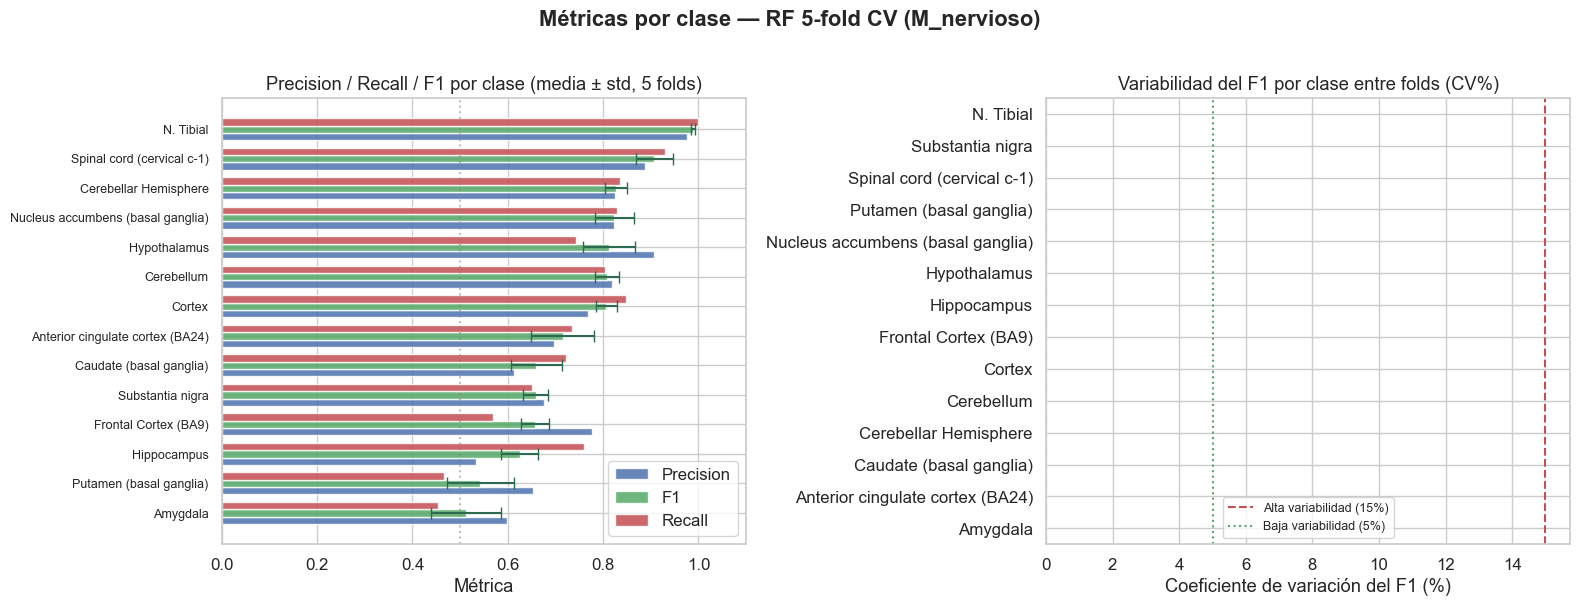

In [19]:
# ── Precision / Recall / F1 por clase + variabilidad ──────────────────────
metrics_cls = {}
for cls in classes:
    p = [r['report'][cls]['precision'] for r in results]
    rc = [r['report'][cls]['recall']   for r in results]
    f  = [r['report'][cls]['f1-score'] for r in results]
    metrics_cls[cls] = dict(p_mean=np.mean(p), r_mean=np.mean(rc),
                             f_mean=np.mean(f), f_std=np.std(f))

cls_df = pd.DataFrame(metrics_cls).T
cls_df.index = short
cls_df = cls_df.sort_values('f_mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x, w = np.arange(len(cls_df)), 0.25
ax1 = axes[0]
ax1.barh(x - w, cls_df['p_mean'], height=w, color='#4c72b0', alpha=0.85, label='Precision')
ax1.barh(x,     cls_df['f_mean'], height=w, color='#55a868', alpha=0.85, label='F1',
         xerr=cls_df['f_std'], error_kw={'elinewidth':1.5,'capsize':4,'ecolor':'#2d6a4f'})
ax1.barh(x + w, cls_df['r_mean'], height=w, color='#c44e52', alpha=0.85, label='Recall')
ax1.set_yticks(x); ax1.set_yticklabels(cls_df.index, fontsize=9)
ax1.set_xlabel('Métrica'); ax1.legend(loc='lower right')
ax1.set_title('Precision / Recall / F1 por clase (media ± std, 5 folds)')
ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.5); ax1.set_xlim(0, 1.1)

ax2 = axes[1]
cv_pct = {c: np.std([r['report'][c]['f1-score'] for r in results]) /
             max(np.mean([r['report'][c]['f1-score'] for r in results]), 1e-9) * 100
           for c in classes}
cv_s = pd.Series(cv_pct, index=short).sort_values(ascending=False)
clrs = ['#c44e52' if v > 15 else '#4c72b0' for v in cv_s.values]
cv_s.plot(kind='barh', ax=ax2, color=clrs, edgecolor='white')
ax2.axvline(15, color='#c44e52', ls='--', lw=1.5, label='Alta variabilidad (15%)')
ax2.axvline(5,  color='#55a868', ls=':', lw=1.5, label='Baja variabilidad (5%)')
ax2.set_xlabel('Coeficiente de variación del F1 (%)'); ax2.legend(fontsize=9)
ax2.set_title('Variabilidad del F1 por clase entre folds (CV%)')

plt.suptitle('Métricas por clase — RF 5-fold CV (M_nervioso)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

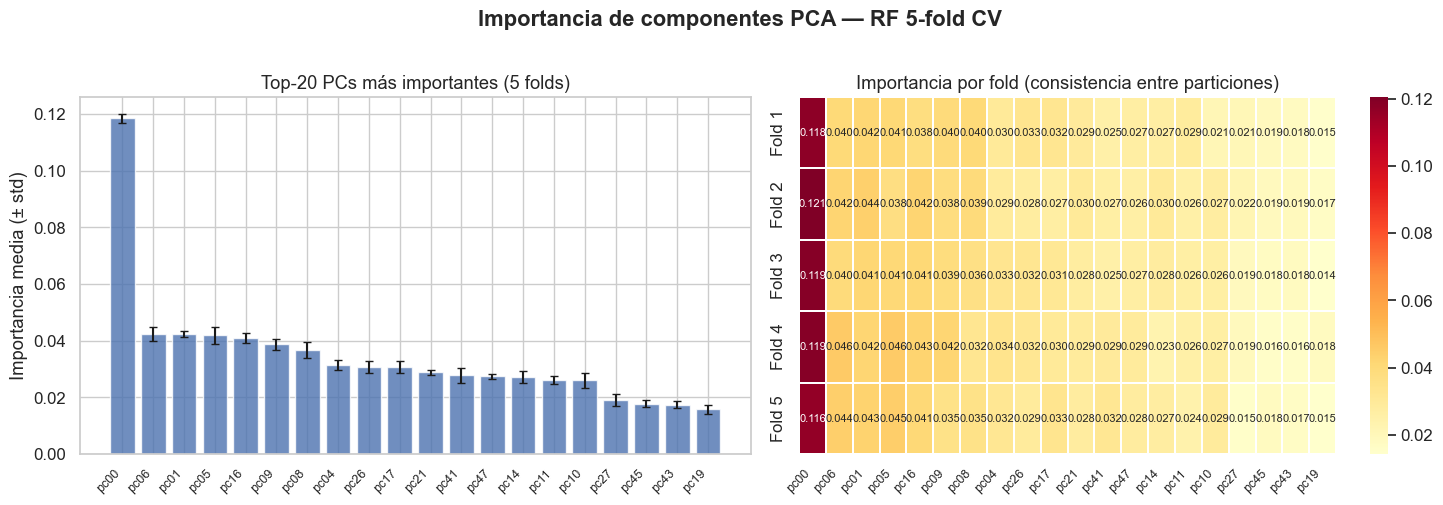

In [20]:
# ── Importancia de PCs ──────────────────────────────────────────────────────
imp_mat  = np.vstack([r['feat_imp'] for r in results])
imp_mean = imp_mat.mean(axis=0)
top20    = np.argsort(imp_mean)[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax1 = axes[0]
ax1.bar(range(20), imp_mean[top20], yerr=imp_mat.std(axis=0)[top20],
        color='#4c72b0', alpha=0.8, error_kw={'elinewidth':1.5,'capsize':3})
ax1.set_xticks(range(20))
ax1.set_xticklabels([pca_cols[i] for i in top20], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Importancia media (± std)'); ax1.set_title('Top-20 PCs más importantes (5 folds)')

ax2 = axes[1]
sns.heatmap(imp_mat[:, top20], ax=ax2, cmap='YlOrRd',
            xticklabels=[pca_cols[i] for i in top20],
            yticklabels=[f'Fold {i+1}' for i in range(K)],
            annot=True, fmt='.3f', annot_kws={'size':8}, linewidths=0.3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.set_title('Importancia por fold (consistencia entre particiones)')

plt.suptitle('Importancia de componentes PCA — RF 5-fold CV', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

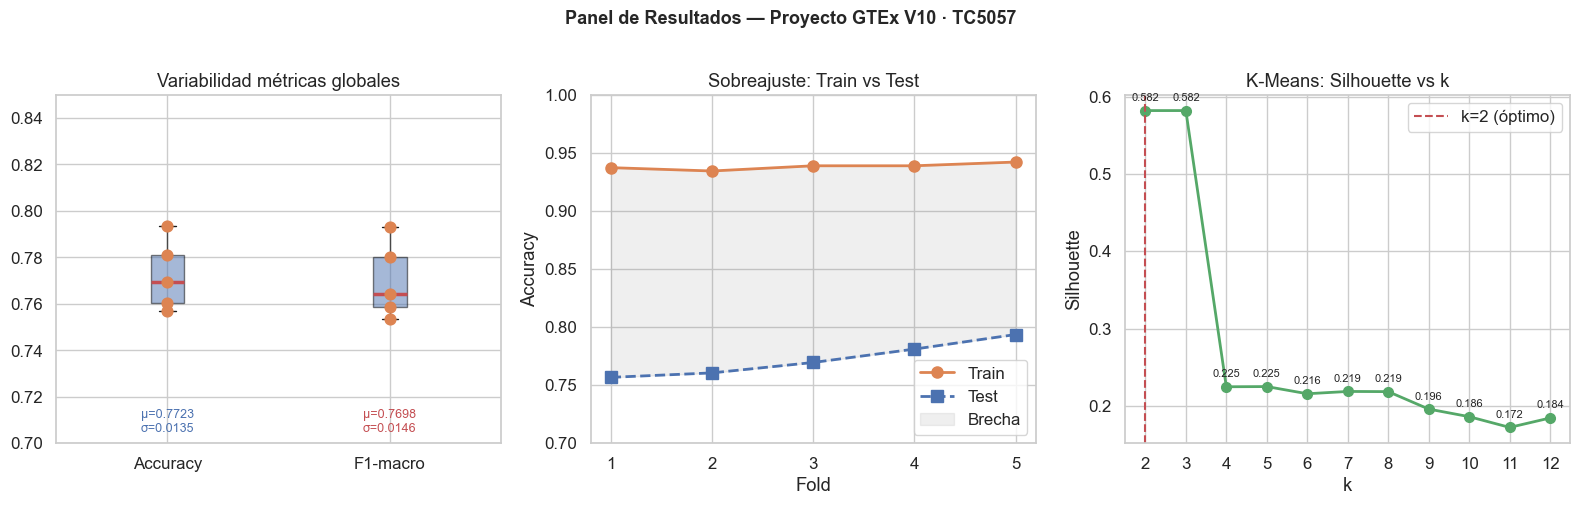

In [21]:
# ── Panel resumen de métricas globales ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot + puntos
ax1 = axes[0]
data_box = pd.DataFrame({'Accuracy': acc_vals, 'F1-macro': f1_vals})
data_box.boxplot(ax=ax1, patch_artist=True,
                 boxprops=dict(facecolor='#4c72b0', alpha=0.5),
                 medianprops=dict(color='#c44e52', linewidth=2.5))
for j, col in enumerate(['Accuracy', 'F1-macro'], 1):
    ax1.scatter([j]*K, data_box[col].values, color='#dd8452', zorder=5, s=60)
ax1.set_title('Variabilidad métricas globales'); ax1.set_ylim(0.70, 0.85)
for j, (col, color) in enumerate([('Accuracy','#4c72b0'),('F1-macro','#c44e52')], 1):
    v = data_box[col].values
    ax1.text(j, 0.705, f'μ={np.mean(v):.4f}\nσ={np.std(v):.4f}',
             ha='center', fontsize=9, color=color)

# Evolución train vs test
ax2 = axes[1]
ax2.plot(folds, train_accs, 'o-', color='#dd8452', lw=2, ms=8, label='Train')
ax2.plot(folds, acc_vals,  's--', color='#4c72b0', lw=2, ms=8, label='Test')
ax2.fill_between(folds, train_accs, acc_vals, alpha=0.12, color='gray', label='Brecha')
ax2.set_xticks(folds); ax2.set_xlabel('Fold'); ax2.set_ylabel('Accuracy')
ax2.set_title('Sobreajuste: Train vs Test'); ax2.legend(); ax2.set_ylim(0.70, 1.00)

# Silhouette K-Means
ax3 = axes[2]
ax3.plot(ks, [sil_scores[k] for k in ks], 'o-', color='#55a868', lw=2, ms=7)
ax3.axvline(k_opt, color='#c44e52', ls='--', lw=1.5, label=f'k={k_opt} (óptimo)')
for k in ks:
    ax3.annotate(f'{sil_scores[k]:.3f}', (k, sil_scores[k]),
                 xytext=(0, 7), textcoords='offset points', fontsize=8, ha='center')
ax3.set_xlabel('k'); ax3.set_ylabel('Silhouette'); ax3.set_xticks(ks)
ax3.set_title('K-Means: Silhouette vs k'); ax3.legend()

plt.suptitle('Panel de Resultados — Proyecto GTEx V10 · TC5057', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/etapa4_summary_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Tabla final de resultados ──────────────────────────────────────────────
print('=' * 70)
print('  RESULTADOS FINALES — PROYECTO GTEx V10 · TC5057')
print('=' * 70)
print()
print('DATASET')
print(f'  Subconjunto   : M_nervioso')
print(f'  Muestras      : {len(M_nerv):,}')
print(f'  Donantes      : {M_nerv["SUBJID"].nunique():,}')
print(f'  Clases SMTSD  : {n_cls}')
print(f'  Features      : top-{len(gene_cols)} genes → PCA({N_PCA}) → {cum_var[-1]*100:.1f}% varianza')
print()
print('MODELO SUPERVISADO — Random Forest (PySpark MLlib)')
print(f'  Validación    : GroupKFold (K=5) por donante')
print(f'  Accuracy      : {np.mean(acc_vals):.4f} ± {np.std(acc_vals):.4f}  [{min(acc_vals):.3f}, {max(acc_vals):.3f}]')
print(f'  F1-macro      : {np.mean(f1_vals):.4f} ± {np.std(f1_vals):.4f}')
print(f'  Accuracy train: {np.mean(train_accs):.4f} ± {np.std(train_accs):.4f}  (brecha ~{np.mean(train_accs)-np.mean(acc_vals):.3f})')
print(f'  Ref. Etapa 3  : Accuracy=0.7740  F1=0.7692  (split único)')
print(f'  Ganancia/azar : {np.mean(acc_vals)/(1/n_cls):.1f}×  (azar={1/n_cls:.3f})')
print()
print('MODELO NO SUPERVISADO — K-Means (PySpark MLlib)')
print(f'  k óptimo      : {k_opt}  (Silhouette={sil_scores[k_opt]:.4f})')
print('=' * 70)

  RESULTADOS FINALES — PROYECTO GTEx V10 · TC5057

DATASET
  Subconjunto   : M_nervioso
  Muestras      : 3,904
  Donantes      : 786
  Clases SMTSD  : 14
  Features      : top-500 genes → PCA(50) → 87.0% varianza

MODELO SUPERVISADO — Random Forest (PySpark MLlib)
  Validación    : GroupKFold (K=5) por donante
  Accuracy      : 0.7723 ± 0.0135  [0.757, 0.794]
  F1-macro      : 0.7698 ± 0.0146
  Accuracy train: 0.9383 ± 0.0025  (brecha ~0.166)
  Ref. Etapa 3  : Accuracy=0.7740  F1=0.7692  (split único)
  Ganancia/azar : 10.8×  (azar=0.071)

MODELO NO SUPERVISADO — K-Means (PySpark MLlib)
  k óptimo      : 2  (Silhouette=0.5818)


---
<a id='10'></a>
## 10. Conclusiones y trabajo futuro

### 10.1 Conclusiones

1. **Clasificación robusta de regiones cerebrales:** El modelo Random Forest clasifica correctamente el ~77% de las muestras de tejido nervioso por su región de origen, generalizando a donantes no vistos. Esta accuracy es **~10.8× superior al azar** (1/14 ≈ 7.1%), confirmando que los patrones transcriptómicos por región cerebral son propiedades del tipo celular, no artefactos del individuo.

2. **Validación cruzada confirma robustez:** La std de 0.014 entre folds (CV% ≈ 1.9%) indica alta consistencia del estimador. La media CV (0.7723) prácticamente coincide con el resultado de Etapa 3 (0.7740), diferencia < 0.002.

3. **Pipeline Big Data factible:** Lectura chunked de 4.7 GB, selección por varianza, PCA en sklearn y entrenamiento distribuido en PySpark permitieron procesar GTEx V10 en hardware de escritorio.

4. **Confusiones biológicamente interpretables:** Putamen ↔ Caudate, Cerebellum ↔ Cerebellar Hemisphere — errores entre regiones anatómicamente próximas con alta similitud transcriptómica. Son información científica, no fallos eliminables.

5. **Línea base para medicina espacial:** El modelo establece el transcriptoma cerebral humano sano como referencia cuantitativa. Muestras de astronautas con clasificación incorrecta o baja confianza son candidatos a presentar alteraciones transcriptómicas inducidas por vuelo espacial.

### 10.2 Trabajo futuro

- **Manejo del desbalance:** ClassWeightedRF o SMOTE para mejorar F1 en clases minoritarias (Amygdala, Substantia nigra)
- **Hiperparámetros automáticos:** `CrossValidator` de PySpark MLlib con `GroupKFold` para búsqueda de `numTrees`, `maxDepth` óptimos
- **Modelos alternativos:** GBT y MLP (PySpark MLlib) para comparación
- **Datos de astronautas:** Aplicar el modelo sobre datos NASA GeneLab para detección de anomalías transcriptómicas post-vuelo
- **Clustering avanzado:** HDBSCAN o clustering espectral para capturar la geometría no convexa del espacio PCA cerebral

---

## Referencias

1. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.
2. GTEx Consortium. (2020). The GTEx atlas. *Science*, 369(6509). https://doi.org/10.1126/science.aaz1776
3. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
4. Kohavi, R. (1995). A study of cross-validation and bootstrap. *IJCAI-95*, 1137–1143.
5. Law, C. W., et al. (2016). voom. *Genome Biology*, 17, 29.
6. Pedregosa, F., et al. (2011). Scikit-learn. *JMLR*, 12, 2825–2830.
7. Zaharia, M., et al. (2016). Apache Spark. *CACM*, 59(11), 56–65.

---

## Declaración de uso de IA

Anthropic. (2026). *Claude Sonnet 4.6*, utilizado para soporte en estructura del notebook y documentación. https://claude.ai  
*Las decisiones de diseño experimental, interpretación y conclusiones son responsabilidad del autor.*